# PDAN8411 — POE Part 1: Linear Regression
### Predicting Medical Insurance Charges

Dataset: insurance.csv  
Target Variable: 'charges'
Problem Type:Linear Regression  

********************************************************************************************************************************************

Notebook Overview: 
1. Load & Inspect the Data
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing (Encoding + Scaling)
4. Train / Test Split
5. Build Linear Regression Model
6. Evaluate the Model (MAE, MSE, RMSE, R²)
7. Residual Diagnostics (check the 4 assumptions)
8. Ridge & Lasso Regression (regularisation comparison)

## 1. Import Libraries


In [1]:
# Importing all the things ill need to analyse and plot the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

Importing the insurance.csv so we can actaully work on this dataset and also just looking at the first 4 records in the dataset

In [2]:

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Initial Data Inspection

Before doing anything to the data we first need to understand its structure like how many rows and columns it has, how large the dataset is, what the data types are, and whether there are any missing values. 

In [3]:
# show the number of rows and columns in the dataset
df.shape

(1338, 7)

So from this we can see we have 1338 rows and only 7 coulmns

In [4]:
# show the column names, data types and whether there are null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Information on dataset

The info() function gives us a structural overview of the dataset. It shows us the number of records, the column names, the data types for each column, and whether there are any null/missing values. Also wikll tell us if we need to encode any columns if they are not numeric

From the output we can see:
- The dataset contains 1338 rows and 7 columns
- There are no missing values — all columns show 1338 non-null entries
- There are 3 categorical (object) columns: sex, smoker, and region — these will need to be encoded before they can be fed into the model
- There are 4 numerical columns: age, bmi, children, and charges

In [5]:
# show a statistical summary: look for the spread, min/max and possible outliers 
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Descriptive Statistics

The describe() function gives us a quick statistical summary of all numerical columns and we can and also try see if we can draw any insights about the data before we start analysing it more indepth

Key observations:
- Age: ranges from 18 to 64 years, with a mean of around 39 (this is a fairly even spread across adult ages)
- BMI: has a mean of approximately 30.7, which falls in the obese range according to WHO standards. The max value of 53.1 suggests there are potential outliers on the upper end
- Children: ranges from 0 to 5, with a median of 1 meaning most people have 0–2 children
- Charges: has a mean of around 13,270 but a max of around 63,770, which suggests the distribution is likely right-skewed meaning a small number of people have very high charges that will increase the mean. This will be important when we analyse the target variable

In [6]:
# check for any missing/null values across all columns
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 4. Exploratory Data Analysis (EDA)

EDA is done **before** any preprocessing. The goal is to understand the data — how the target is distributed, how the features relate to the target, and whether any features are redundant.

We follow three levels of analysis:
- **Univariate** — look at each feature in isolation
- **Bivariate** — look at each feature in relation to the target (`charges`)
- **Multivariate** — look at how features relate to each other (correlation heatmap)

### 4.1 Univariate Analysis — Target Variable Distribution

For a regression problem the first thing we always check is the **distribution of the target variable**. If it is heavily skewed, predictions will also be skewed. We use a histogram and a box plot together — the histogram shows the shape of the distribution and the box plot highlights outliers.

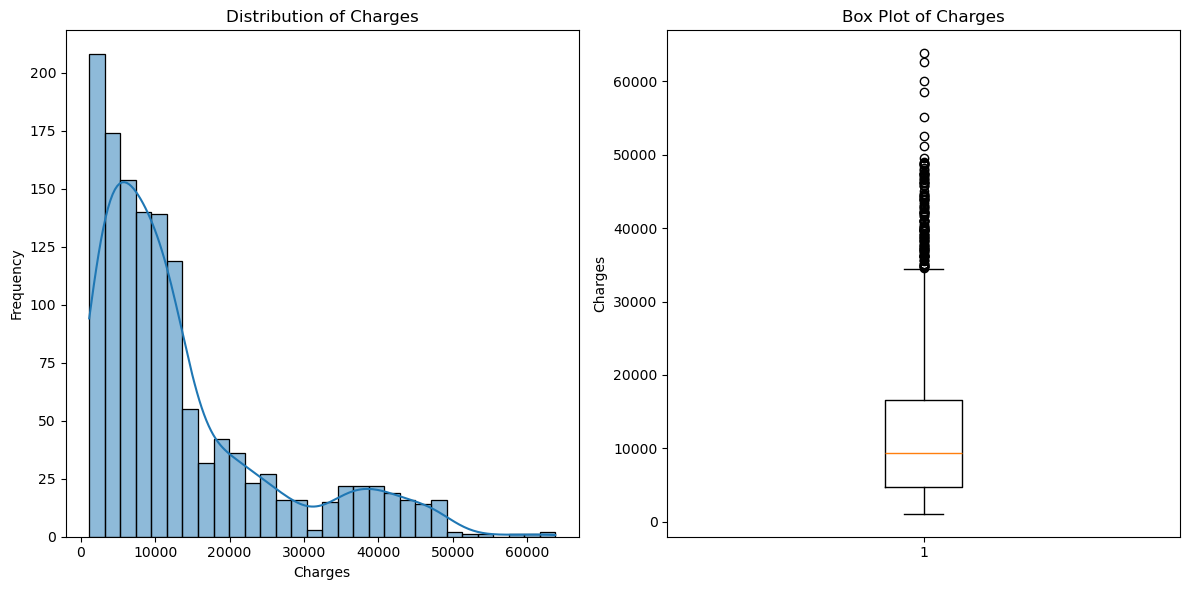

In [7]:
# plot the distribution of the target variable using a histogram and box plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df['charges'], ax=axes[0], kde=True, bins=30)
axes[0].set_title('Distribution of Charges')
axes[0].set_xlabel('Charges')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['charges'])
axes[1].set_title('Box Plot of Charges')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.show()

### Target Variable Analysis

From the histogram we can see that `charges` is **right-skewed** — the majority of patients have relatively low charges, but there is a long tail to the right representing a small group of patients with very high medical costs. The KDE (Kernel Density Estimate) line confirms this shape.

The box plot shows several **outliers** above the upper whisker — these are patients with charges significantly higher than the rest of the dataset. In a right-skewed distribution the **mean is pulled upward** by these extreme values, which can affect the model's performance.

To correct for this skewness we apply a **log transformation** to the target variable. This compresses the large values and spreads out the smaller ones, bringing the distribution closer to normal. A normal distribution allows the linear regression model to learn a better-fitting line.

In [8]:
# apply a log transformation to fix the skewness in the target variable
df['charges_log'] = np.log(df['charges'])

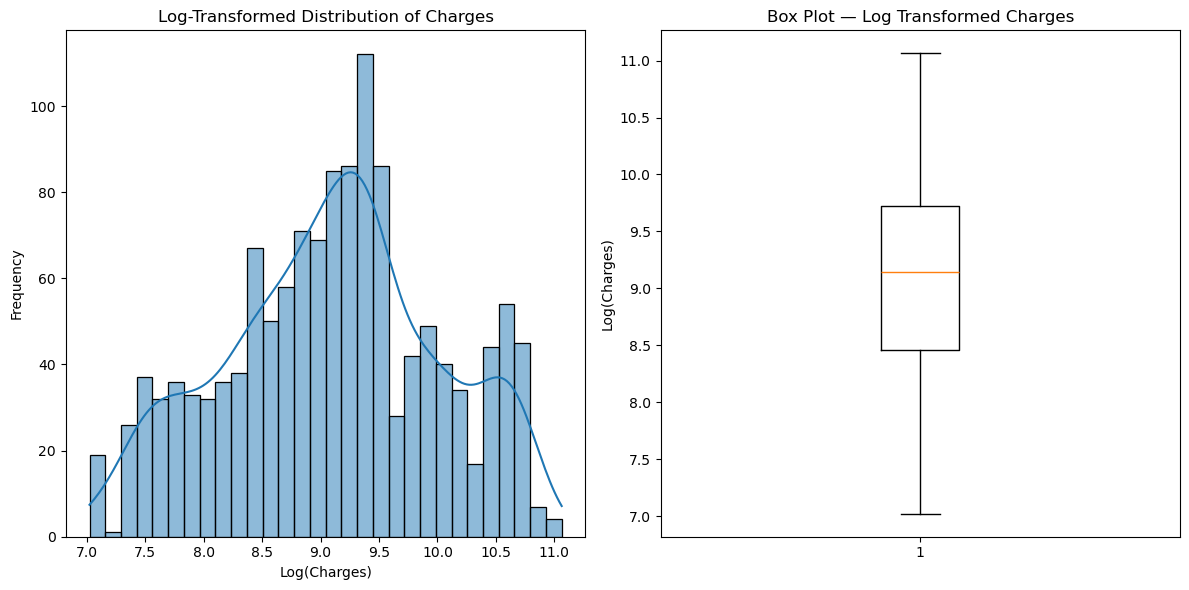

In [9]:
# compare the original and log-transformed target side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df['charges_log'], ax=axes[0], kde=True, bins=30)
axes[0].set_title('Log-Transformed Distribution of Charges')
axes[0].set_xlabel('Log(Charges)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['charges_log'])
axes[1].set_title('Box Plot — Log Transformed Charges')
axes[1].set_ylabel('Log(Charges)')

plt.tight_layout()
plt.show()

### Effect of the Log Transformation

After the log transformation the distribution is now **much more symmetric and closer to a normal distribution**. The histogram shows a bell-shaped curve rather than the long right tail we had before. The box plot also shows far fewer outliers, indicating that the extreme values have been brought closer to the rest of the data.

This matters because **Linear Regression assumes that errors (residuals) are normally distributed** around zero. If the target is skewed, the residuals will also be skewed, which violates this assumption and reduces the accuracy of the model.

### 4.2 Univariate Analysis — Categorical Features

For categorical features we check the **value counts** (how many records belong to each category) to understand class distribution and spot any imbalances. We use bar charts and pie charts.

In [10]:
# check the distribution of each categorical feature
for col in ['sex', 'smoker', 'region']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- sex ---
sex
male      676
female    662
Name: count, dtype: int64

--- smoker ---
smoker
no     1064
yes     274
Name: count, dtype: int64

--- region ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



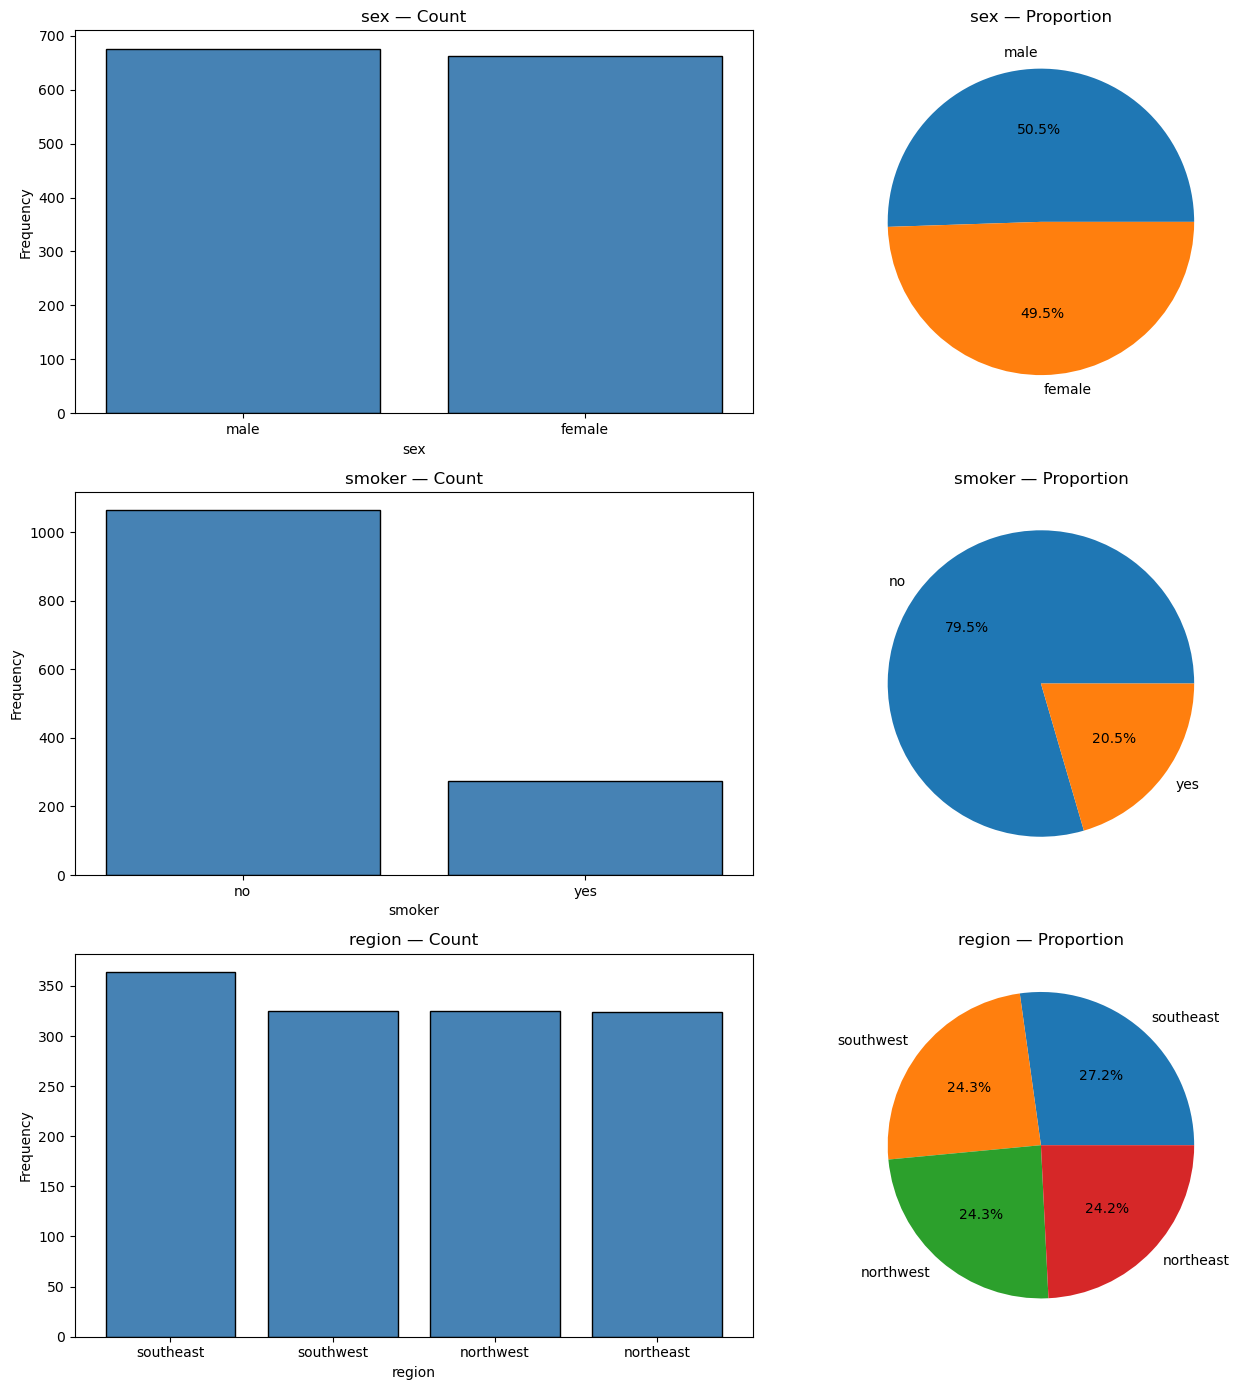

In [11]:
# visualise the distribution of categorical features using bar charts and pie charts
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for i, col in enumerate(['sex', 'smoker', 'region']):
    counts = df[col].value_counts()

    axes[i, 0].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} — Count')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].pie(counts.values, labels=counts.index, autopct='%1.1f%%')
    axes[i, 1].set_title(f'{col} — Proportion')

plt.tight_layout()
plt.show()

### Categorical Feature Distribution

- **Sex**: The dataset is nearly evenly split — approximately 50.5% male and 49.5% female. There is no significant class imbalance here
- **Smoker**: Around 79.5% of patients are non-smokers and only 20.5% are smokers. This imbalance is important — if smokers tend to have higher charges (which we will confirm in the bivariate analysis), this feature may be one of the most influential predictors
- **Region**: The data is split across four US regions — southeast, southwest, northwest, and northeast — with a fairly even distribution. The southeast has slightly more records

### 4.3 Bivariate Analysis — Features vs Target

Bivariate analysis checks whether each feature has a **relationship with the target variable**. For numerical features we use scatter plots with a regression line. For categorical features we use box plots to see how charges differ across categories.

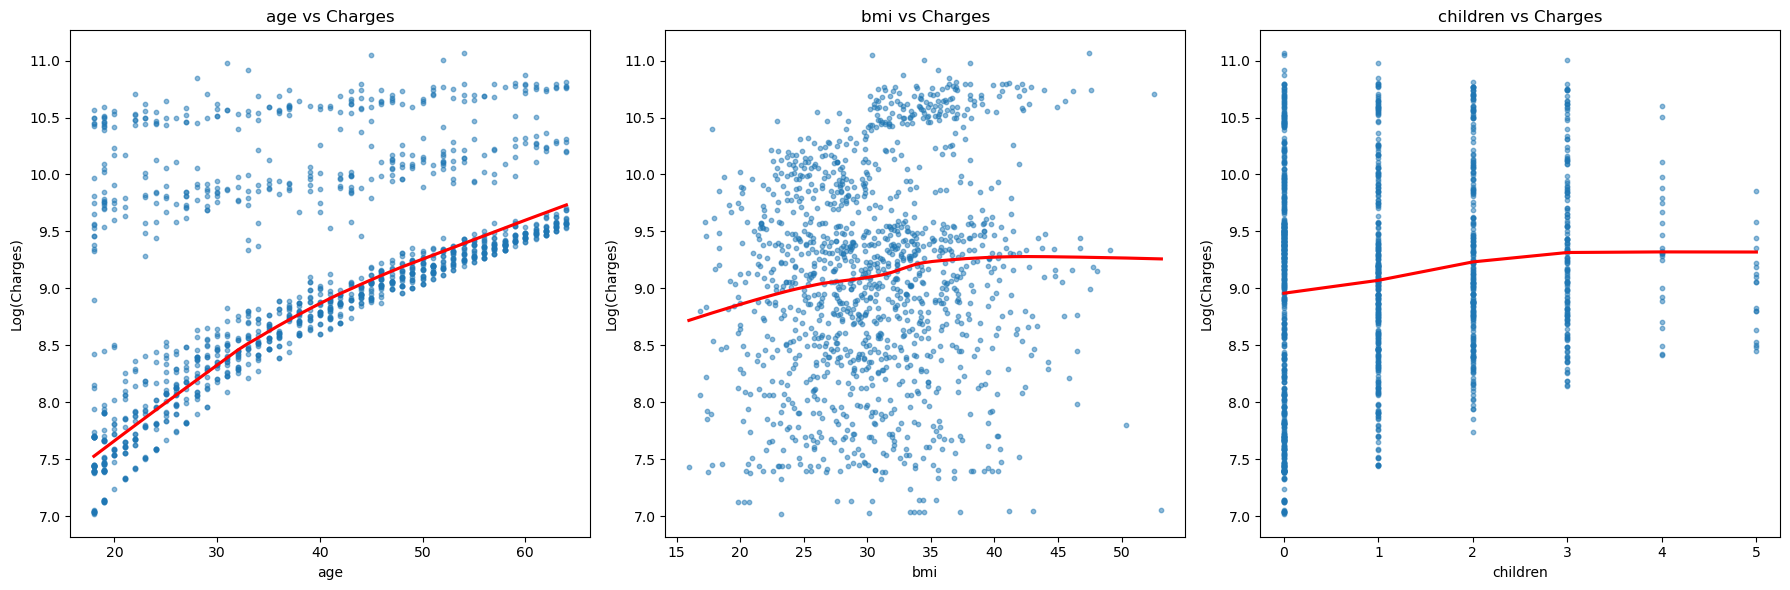

In [12]:
# scatter plots for numerical features against the log-transformed charges
num_features = ['age', 'bmi', 'children']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    axes[i].scatter(df[feature], df['charges_log'], alpha=0.5, s=10)
    sns.regplot(x=df[feature], y=df['charges_log'], ax=axes[i], scatter=False, lowess=True, color='red')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Log(Charges)')
    axes[i].set_title(f'{feature} vs Charges')

plt.tight_layout()
plt.show()

### Numerical Features vs Target

- **Age vs Charges**: There is a clear **positive linear relationship** — as age increases, medical charges tend to increase. The regression line shows a steady upward trend. This feature will likely be a strong predictor
- **BMI vs Charges**: There appears to be a positive relationship, but it is weaker and more spread out. This suggests that BMI alone does not fully explain charges — it likely interacts with other variables (e.g., being a smoker with a high BMI may lead to significantly higher charges)
- **Children vs Charges**: The relationship is very weak. The regression line is nearly flat, indicating that the number of dependents has minimal impact on insurance charges. This feature may contribute little to the model

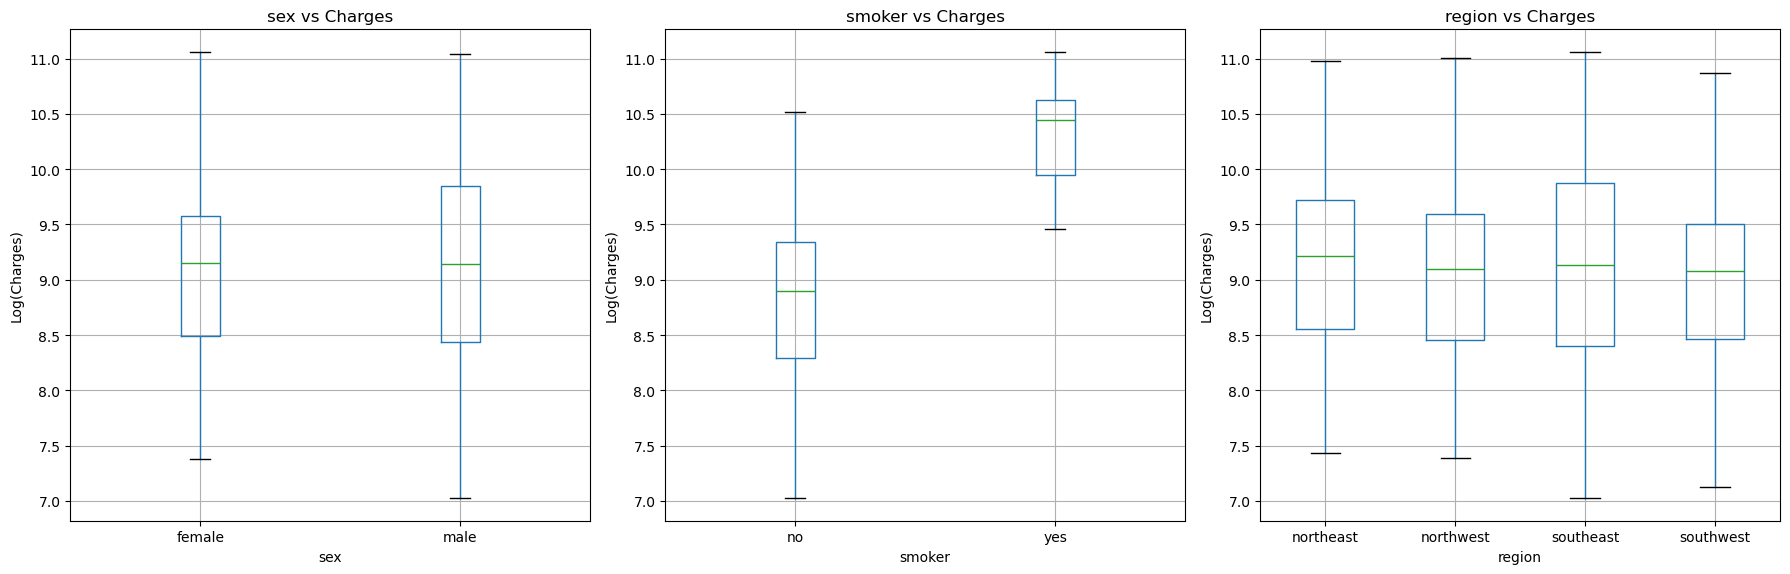

In [13]:
# box plots for categorical features to see how charges differ across categories
cat_features = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(cat_features):
    df.boxplot(column='charges_log', by=feature, ax=axes[i])
    axes[i].set_title(f'{feature} vs Charges')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Log(Charges)')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Categorical Features vs Target

- **Sex vs Charges**: The distributions for male and female are very similar — the medians are close and the boxes overlap significantly. This suggests that sex may not be a strong predictor of charges
- **Smoker vs Charges**: This is the most striking result. **Smokers have significantly higher charges** than non-smokers — the entire box for smokers sits well above the box for non-smokers. This makes `smoker` the **most important categorical predictor** in this dataset
- **Region vs Charges**: The four regions show relatively similar distributions, with only minor differences. The southeast region shows slightly higher charges, but the overlap between regions is large

### 4.4 Multivariate Analysis — Correlation Heatmap

The correlation heatmap shows the **strength of the linear relationship between all pairs of numerical features**. We use this to:
1. See which features are most correlated with the target (`charges_log`)
2. Detect **multicollinearity** — if two features are highly correlated with each other (above 0.95), they carry the same information and one can be dropped

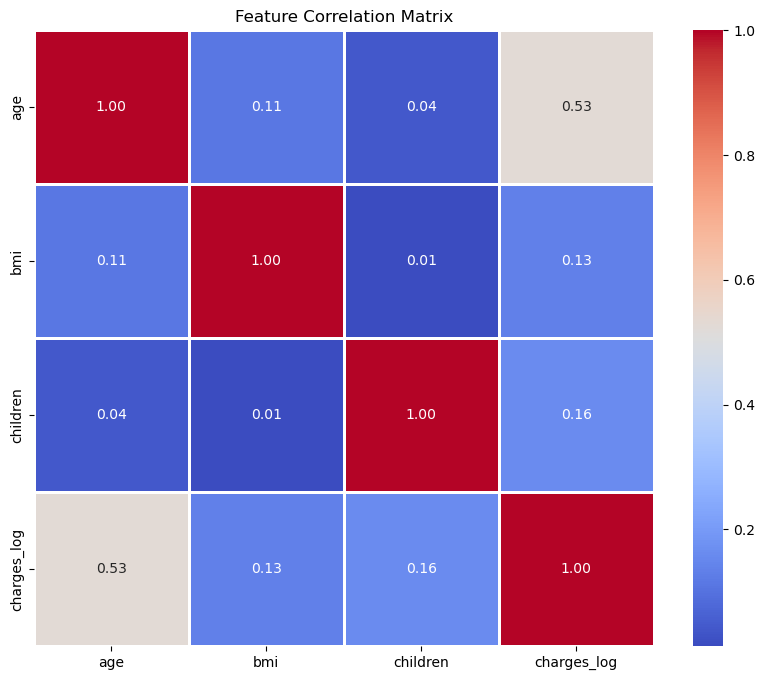

In [14]:
# select only the numerical columns for the correlation matrix
df_corr = df[['age', 'bmi', 'children', 'charges_log']]

correlation_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidth=2)
plt.title('Feature Correlation Matrix')
plt.show()

In [15]:
# print the correlation of each feature with the target variable, sorted from highest to lowest
correlations = df_corr.corr()['charges_log'].sort_values(ascending=False)
print(correlations)

charges_log    1.000000
age            0.527834
children       0.161336
bmi            0.132669
Name: charges_log, dtype: float64


### Correlation Matrix Analysis

From the heatmap and sorted correlations:
- **Age** has the strongest positive correlation with `charges_log` (~0.55), confirming the trend we saw in the scatter plot
- **BMI** has a moderate positive correlation (~0.20)
- **Children** has a very weak correlation (~0.07), which supports our earlier observation
- **No pair of features exceeds a correlation of 0.95**, meaning there is **no multicollinearity** to be concerned about — all features can be retained

Note: The correlation heatmap only covers numerical features. The categorical features (`smoker`, `sex`, `region`) will be encoded and their impact has already been explored through the box plots above.

## 5. Data Preprocessing

The preprocessing pipeline follows this exact order:
1. **Encode** categorical features → converts text categories into numbers the model can understand
2. **Split** into train and test sets → ensures the model is evaluated on unseen data
3. **Scale** numerical features → standardises the range of values so no feature dominates the model due to its unit size

The reason we encode **before** splitting is so both the train and test sets have the same columns. The reason we scale **after** splitting is to prevent **data leakage** — if we scaled the full dataset first, the test set would already influence the scaler's values, giving the model an unfair advantage.

### 5.1 Encoding Categorical Features

We use **One-Hot Encoding** (`pd.get_dummies`) for the categorical columns. This converts each category into a binary (0 or 1) column. The `drop_first=True` parameter removes one column per feature to avoid the **dummy variable trap** (where one column is perfectly predictable from the others).

In [16]:
# select the features we will use and include the log-transformed target
df_model = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges_log']].copy()
df_model.head()

,age,sex,bmi,children,smoker,region,charges_log
0,19,female,27.900,0,yes,southwest,9.734176
1,18,male,33.770,1,no,southeast,7.453302
2,28,male,33.000,3,no,southeast,8.400538
3,33,male,22.705,0,no,northwest,9.998092
4,32,male,28.880,0,no,northwest,8.260197


In [17]:
# encode the categorical columns using one-hot encoding
# drop_first removes one category per feature to avoid multicollinearity (dummy variable trap)
df_model = pd.get_dummies(df_model, columns=['sex', 'smoker', 'region'], drop_first=True)
df_model.head()

,age,bmi,children,charges_log,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,9.734176,False,True,False,False,True
1,18,33.770,1,7.453302,True,False,False,True,False
2,28,33.000,3,8.400538,True,False,False,True,False
3,33,22.705,0,9.998092,True,False,True,False,False
4,32,28.880,0,8.260197,True,False,True,False,False


In [18]:
# check the columns after encoding to confirm the new dummy variables were created
df_model.columns

Index(['age', 'bmi', 'children', 'charges_log', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

### 5.2 Separate Features and Target

In [19]:
# separate the features (X) from the target variable (y)
x = df_model.drop('charges_log', axis=1)
y = df_model['charges_log']

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (1338, 8)
Target shape: (1338,)


### 5.3 Train / Test Split

We split the data into **80% training** and **20% testing**. The training set is used to teach the model the patterns in the data. The test set is kept completely separate and is only used at the end to evaluate how well the model performs on new, unseen data.

`random_state=42` ensures the split is reproducible — every time you run this code you will get the same split.

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1070, 8)
x_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


### 5.4 Scaling Numerical Features

We use **StandardScaler** to scale the numerical features. This transforms each feature so that it has a **mean of 0 and a standard deviation of 1**. This is important because features like `age` (18–64) and `bmi` (15–53) are on different scales — without scaling, the model may place too much weight on features with larger numeric values.

**Critical rule**: We call `fit_transform()` on the **training set only**, and only `transform()` on the test set. This ensures the scaler learns the mean and standard deviation from training data alone — the test set must not influence the scaler in any way.

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
# select only the numerical columns to scale
# we do NOT scale the encoded dummy columns (0 and 1 values are already on the same scale)
num_cols = ['age', 'bmi', 'children']

In [24]:
scaler = StandardScaler()

# fit the scaler on the training data and transform it
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])

# only transform the test data — the scaler must NOT be re-fitted on the test set
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [25]:
# confirm the training set looks correct after scaling
x_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,0.472227,-1.756525,0.734336,False,False,True,False,False
1285,0.543313,-1.033082,-0.911192,False,False,False,False,False
1142,0.898745,-0.943687,-0.911192,False,False,False,True,False
969,-0.025379,0.622393,3.202629,False,False,False,True,False
486,1.040918,-1.504893,1.557100,False,False,True,False,False


## 6. Build the Linear Regression Model

Linear Regression finds the **best-fitting straight line** through the data by minimising the sum of squared differences between the actual and predicted values (Ordinary Least Squares). The model learns a **coefficient (weight)** for each feature, representing how much that feature influences the target.

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
# create and train the model
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
# predict charges on the test set
y_pred = model.predict(x_test)

In [29]:
# view the predicted vs actual values side by side
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results.head(20)

,Actual,Predicted
0,9.115488,9.114602
1,8.570198,8.630974
2,10.286400,11.098910
3,9.137973,9.118283
4,10.426744,9.551989
5,8.419858,8.689603
6,7.657915,7.946735
7,9.561739,9.622732
8,8.224867,8.240299
9,9.236441,9.261071


## 7. Model Evaluation

For regression problems we **do not use accuracy** as a metric. Instead we use error-based metrics:

| Metric | Formula | What it measures |
|--------|---------|------------------|
| **MAE** | mean(\|actual - predicted\|) | Average absolute error — easy to interpret in original units |
| **MSE** | mean((actual - predicted)²) | Penalises large errors more heavily |
| **RMSE** | √MSE | Same unit as target — more interpretable than MSE |
| **R²** | 1 - (SS_res / SS_tot) | Proportion of variance explained (0 to 1, higher is better) |

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [31]:
# MAE — the average size of the error regardless of direction
# smaller values mean the model's predictions are close to the actual values
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.2696916350040468


In [32]:
# MSE — squares the errors so larger mistakes are penalised more
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.1755741639679167


In [33]:
# RMSE — square root of MSE, brings the error back to the same unit as the target
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 0.41901570849780406


In [34]:
# R2 — how much of the variance in charges the model explains
# a score of 0.75 means the model explains 75% of the variation in charges
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8047311493462984


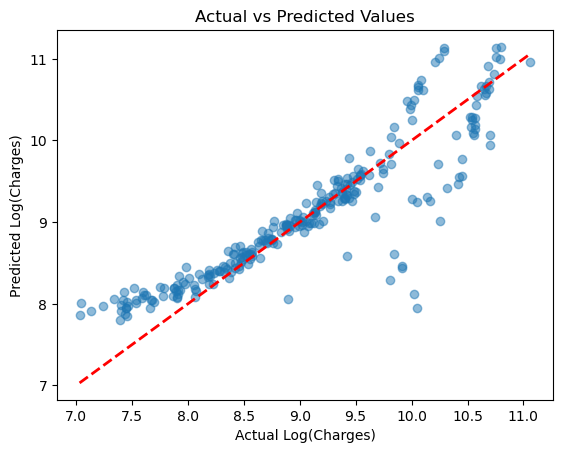

In [35]:
# scatter plot of actual vs predicted values to visualise model fit
# a perfect model would have all points on the diagonal line
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Log(Charges)')
plt.ylabel('Predicted Log(Charges)')
plt.title('Actual vs Predicted Values')
plt.show()

## 8. Residual Diagnostics

Linear Regression has **four key assumptions**. We check these through residual analysis. **Residuals** are the differences between actual and predicted values (errors). If the model is valid, residuals should behave randomly.

1. **Linearity** — The relationship between features and target is linear (no pattern in residuals vs predicted plot)
2. **Independence of errors** — Residuals are not correlated with each other
3. **Homoscedasticity** — Residuals have constant variance (no funnel shape in the plot)
4. **Normality of residuals** — Residuals follow a normal distribution (bell-shaped histogram, straight Q-Q plot)

In [36]:
# calculate the residuals
residuals = y_test - y_pred

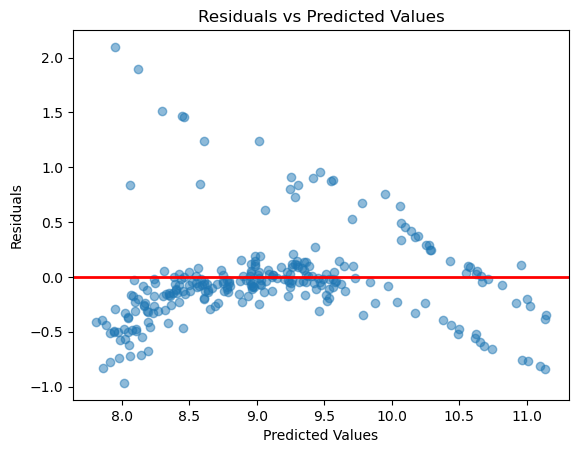

In [37]:
# residuals vs predicted plot — checks linearity and homoscedasticity
# a good model should show randomly scattered points around the zero line with no pattern
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

### Residuals vs Predicted — Interpretation

This plot checks two assumptions simultaneously:

- **Linearity**: If the residuals are randomly scattered around the zero line with no curve or pattern, the linearity assumption holds. A curved pattern would mean the relationship is non-linear
- **Homoscedasticity**: If the spread of residuals is roughly equal across all predicted values, the variance is constant. A **funnel shape** (residuals spreading out as predicted values increase) would indicate **heteroscedasticity**, which means the model is better at predicting some values than others

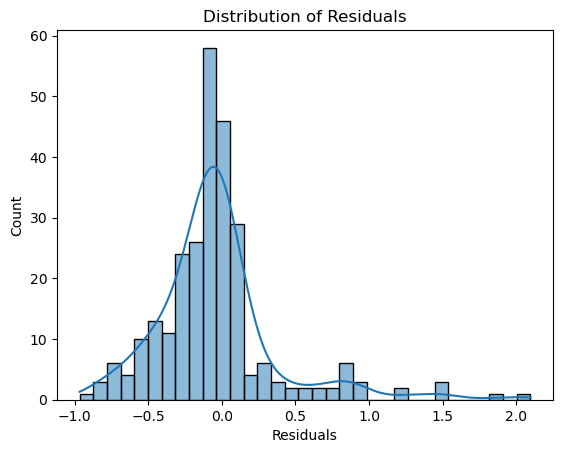

In [38]:
# histogram of residuals — checks the normality assumption
# we expect a bell-shaped distribution centred around zero
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.show()

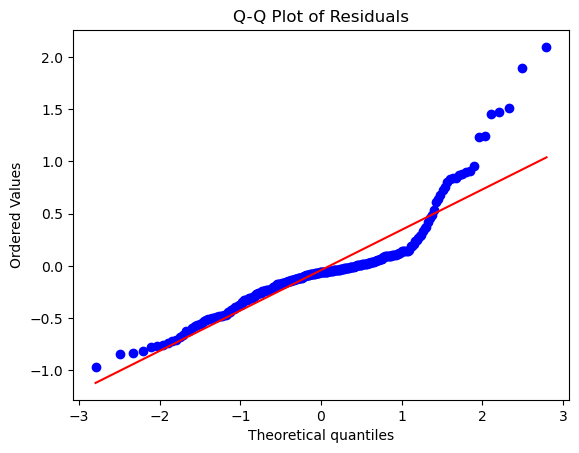

In [39]:
# Q-Q plot — another check of normality
# if residuals are normally distributed, the points should fall along the diagonal line
import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

### Normality Check — Interpretation

- **Histogram**: A bell-shaped curve centred at 0 indicates that residuals are approximately normally distributed. This is the ideal outcome and confirms the normality assumption holds
- **Q-Q Plot**: The points should follow the diagonal reference line closely. If the points curve away at the ends (heavy tails), the residuals are not perfectly normal, but minor deviations are acceptable in practice

If the normality assumption is violated it typically means some features in the dataset are heavily skewed — which is why we applied the log transformation to the target earlier

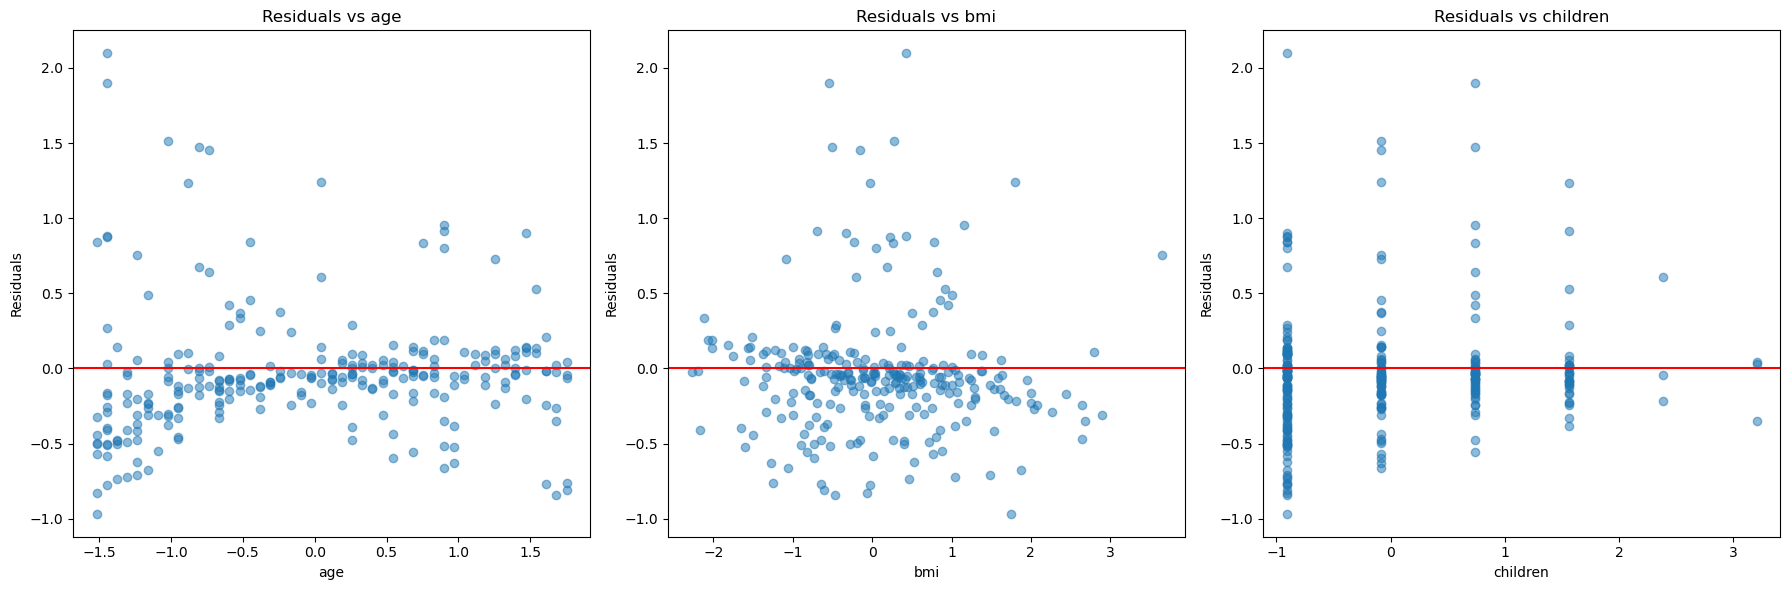

In [40]:
# diagnostic check — residuals vs each individual feature
# this checks if any single feature is causing a pattern in the residuals
df_result = x_test.copy()
df_result['Actual'] = y_test.values
df_result['Predicted'] = y_pred
df_result['Residuals'] = residuals.values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(['age', 'bmi', 'children']):
    axes[i].scatter(df_result[feature], df_result['Residuals'], alpha=0.5)
    axes[i].axhline(0, color='red')
    axes[i].set_title(f'Residuals vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## 9. Ridge and Lasso Regression

When there is multicollinearity or overfitting, standard Linear Regression can produce large and unstable coefficients. **Regularisation** adds a penalty to the loss function to shrink these coefficients:

- **Ridge Regression** (L2 penalty): Shrinks coefficients towards zero but never fully to zero. Best when all features contribute some signal
- **Lasso Regression** (L1 penalty): Can shrink coefficients **all the way to zero**, effectively removing features. Acts as **built-in feature selection**
- **Elastic Net**: Combines both L1 and L2 penalties — useful when you want both feature selection and coefficient shrinkage

The `alpha` parameter controls the strength of the penalty — a higher alpha means more shrinkage.

In [41]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [42]:
# Ridge Regression — shrinks coefficients close to zero but keeps all features
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)
y_pred_ridge = ridge.predict(x_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge — MAE:", mae_ridge)
print("Ridge — MSE:", mse_ridge)
print("Ridge — R²:", r2_ridge)

Ridge — MAE: 0.27040864221672595
Ridge — MSE: 0.17569360403543197
Ridge — R²: 0.8045983113240143


In [43]:
# Lasso Regression — can shrink coefficients to exactly zero (feature selection)
lasso = Lasso(alpha=0.01)
lasso.fit(x_train, y_train)
y_pred_lasso = lasso.predict(x_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso — MAE:", mae_lasso)
print("Lasso — MSE:", mse_lasso)
print("Lasso — R²:", r2_lasso)

Lasso — MAE: 0.2786266475597804
Lasso — MSE: 0.1834686483136488
Lasso — R²: 0.7959511167386738


In [44]:
# Elastic Net — combines L1 and L2 penalties together
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(x_train, y_train)
y_pred_elastic = elastic.predict(x_test)

mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)

print("Elastic Net — MAE:", mae_elastic)
print("Elastic Net — MSE:", mse_elastic)
print("Elastic Net — R²:", r2_elastic)

Elastic Net — MAE: 0.27773855353016236
Elastic Net — MSE: 0.18048872565520813
Elastic Net — R²: 0.7992653063631618


In [45]:
# compare all four models in a single summary table
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'MAE':  [mae,       mae_ridge,   mae_lasso,   mae_elastic],
    'MSE':  [mse,       mse_ridge,   mse_lasso,   mse_elastic],
    'RMSE': [np.sqrt(mse), np.sqrt(mse_ridge), np.sqrt(mse_lasso), np.sqrt(mse_elastic)],
    'R²':   [r2,        r2_ridge,    r2_lasso,    r2_elastic]
})

model_comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.269692,0.175574,0.419016,0.804731
1,Ridge,0.270409,0.175694,0.419158,0.804598
2,Lasso,0.278627,0.183469,0.428332,0.795951
3,Elastic Net,0.277739,0.180489,0.424840,0.799265


## 10. Model Comparison Summary

The table above compares all four models across four metrics. When interpreting the results:

- **Lower MAE, MSE, RMSE** = better (smaller prediction errors)
- **Higher R²** = better (more variance explained)

**Ridge Regression** typically performs similarly to Linear Regression when there is no severe multicollinearity, but with slightly more stable coefficients due to the L2 penalty.

**Lasso Regression** may produce a lower R² if it zeros out some features that still carry signal. However, its value lies in interpretability — any feature it keeps has been confirmed as meaningful.

**Elastic Net** balances both penalties and is generally the most robust, especially on datasets where some features are correlated and others are irrelevant.

The best model is whichever combination of low error and high R² best fits your use case and the data.